# Bias, Variance, and Learning Curves


## Introduction

Building a machine learning model involves more than achieving good performance on a dataset. When a model performs poorly, it is important to understand why. Poor performance may result from a model being too simple to capture underlying patterns, or too complex and overly sensitive to noise in the training data.

The concepts of bias and variance provide a useful framework for diagnosing model behavior and guiding improvement efforts. By examining training and cross-validation performance, practitioners can identify whether a model is underfitting or overfitting and make informed decisions about what to try next.

In this notebook, we investigate bias, variance, learning curves, and regularization through a series of experiments on a synthetic regression dataset.


## Objective

The goal of this notebook is to understand how bias and variance influence machine learning model performance and how these issues can be diagnosed using quantitative evaluation techniques.

Specifically, we aim to:

* Understand the concepts of bias and variance.
* Learn how to diagnose underfitting and overfitting.
* Investigate how model complexity affects performance.
* Use learning curves to analyze model behavior.
* Explore the effect of regularization on highly flexible models.
* Develop intuition for deciding what improvements to make when a model performs poorly.

### Guiding Question

How can we determine whether poor model performance is caused by underfitting or overfitting, and what actions can be taken to address these issues?


## Background Theory

### Bias and Variance

Bias refers to error introduced by simplifying assumptions made by a model. High-bias models are often too simple to capture important relationships within the data and tend to underfit.

Variance refers to a model's sensitivity to variations in the training data. High-variance models often fit the training data extremely well but struggle to generalize to unseen examples, resulting in overfitting.

An effective machine learning model seeks a balance between bias and variance, achieving strong performance on both training and unseen data.

### Diagnosing Bias and Variance

Training and cross-validation errors provide valuable clues about model behavior.

High training error and high cross-validation error typically indicate high bias. In this situation, the model lacks sufficient complexity to learn the underlying patterns in the data.

Low training error combined with significantly higher cross-validation error often indicates high variance. In this case, the model fits the training data well but fails to generalize effectively.

By comparing these errors, practitioners can identify the source of poor performance and choose appropriate corrective actions.

### Learning Curves

Learning curves visualize model performance as the amount of training data increases.

By plotting training and cross-validation errors against training set size, we can gain insight into whether a model suffers from high bias or high variance.

Learning curves are particularly useful when deciding whether collecting additional data is likely to improve performance.

### Regularization

Regularization is a technique used to reduce model complexity and improve generalization.

By penalizing large model parameters, regularization discourages overly complex solutions that may fit noise present in the training data.

Regularization is particularly effective when dealing with high-variance models and plays an important role in controlling overfitting.

## Dataset Generation

To study bias, variance, and learning curves in a controlled setting, a synthetic regression dataset is used.

The dataset is generated from a sinusoidal function with added Gaussian noise. This provides a non-linear relationship that can be approximated with polynomial regression models of varying complexity while remaining simple to visualize and analyze.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge


In [2]:
np.random.seed(42)

In [3]:
#Reusing the detatset from previous notebook

#Generate targets
x = np.linspace(-3, 3, 100)

#Generate targets
y = np.sin(x) + np.random.normal(0, 0.2, size=x.shape)

#Reshape for sktlearn
X = x.reshape(-1, 1)

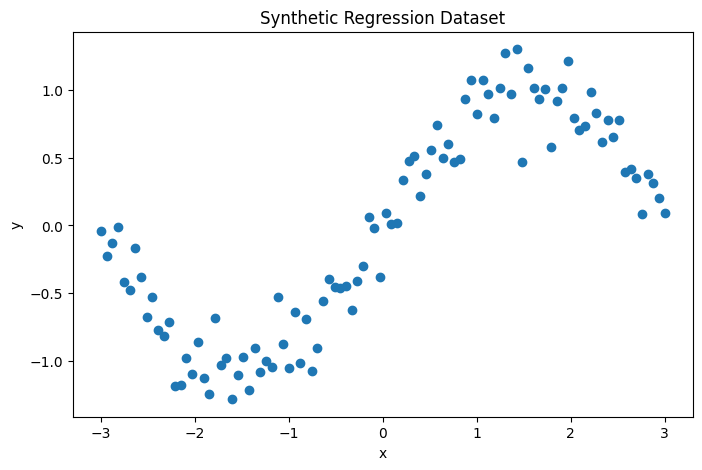

In [4]:
#Plot the data
plt.figure(figsize=(8, 5))
plt.scatter(X, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Regression Dataset")
plt.show()

## Train, Cross-Validation, and Test Split

The dataset is divided into training, cross-validation, and test sets.

The training set is used to fit model parameters. The cross-validation set is used to diagnose model behavior and compare candidate models. The test set is reserved for final evaluation and remains untouched during development.

This separation allows us to distinguish between fitting performance and generalization performance.

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)

X_cv, X_test, y_cv, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print("Training:", X_train.shape[0])
print("CV:", X_cv.shape[0])
print("Test:", X_test.shape[0])

Training: 60
CV: 20
Test: 20


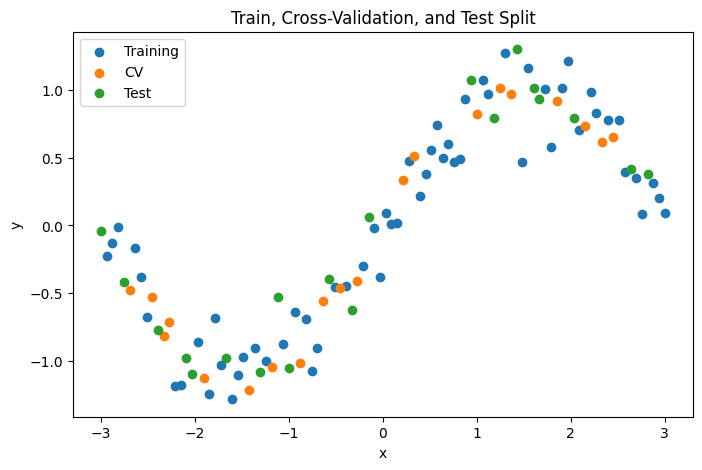

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, label="Training")
plt.scatter(X_cv, y_cv, label="CV")
plt.scatter(X_test, y_test, label="Test")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Train, Cross-Validation, and Test Split")
plt.legend()

plt.show()

## Diagnosing Bias and Variance

To investigate the relationship between model complexity and model performance, polynomial regression models with varying degrees will be trained and evaluated.

The experiment compares:

- Degree 1
- Degree 3
- Degree 5
- Degree 10

Training and cross-validation errors will be used to diagnose whether each model exhibits high bias or high variance.

In [7]:
degrees = [1, 3, 5, 10]

train_errors = []
cv_errors = []

In [8]:
for degree in degrees:

    #Create Polynomial Features
    poly = PolynomialFeatures(
        degree= degree,
        include_bias= False
    )

    #Transform Datasets
    X_train_poly = poly.fit_transform(X_train)
    X_cv_poly    = poly.transform(X_cv)

    #Train model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    #Predictions
    train_pred = model.predict(X_train_poly)
    cv_pred = model.predict(X_cv_poly)

    #Errors
    train_mse = mean_squared_error(y_train, train_pred)
    cv_mse = mean_squared_error(y_cv, cv_pred)

    train_errors.append(train_mse)
    cv_errors.append(cv_mse)

In [9]:
for degree, train, cv in zip(
    degrees,
    train_errors,
    cv_errors
):
    print(
        f"Degree {degree}: "
        f"Train={train:.4f}, "
        f"CV={cv:.4f}"
    )

Degree 1: Train=0.2463, CV=0.1833
Degree 3: Train=0.0386, CV=0.0187
Degree 5: Train=0.0365, CV=0.0118
Degree 10: Train=0.0314, CV=0.0240


In [10]:
import pandas as pd

results = pd.DataFrame({
    "Degree": degrees,
    "Train MSE": train_errors,
    "CV MSE": cv_errors
})

results

,Degree,Train MSE,CV MSE
0,1,0.246264,0.183344
1,3,0.038550,0.018725
2,5,0.036483,0.011821
3,10,0.031402,0.023992


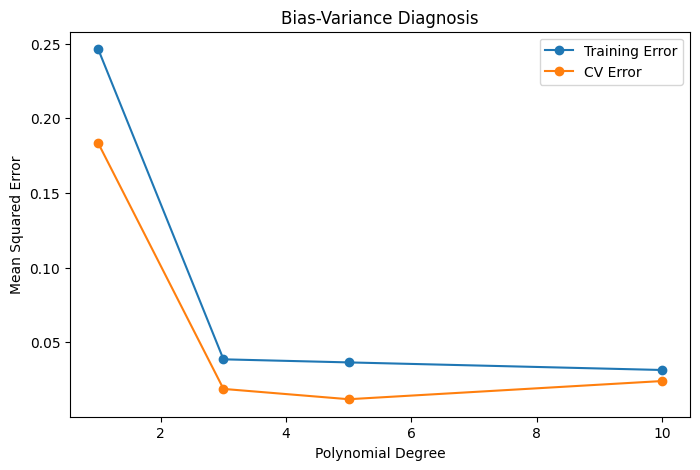

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    degrees,
    train_errors,
    marker="o",
    label="Training Error"
)

plt.plot(
    degrees,
    cv_errors,
    marker="o",
    label="CV Error"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Bias-Variance Diagnosis")
plt.legend()

plt.show()

## Learning Curves

Learning curves provide insight into how model performance changes as additional training data becomes available.

By examining training and cross-validation errors across different training set sizes, we can diagnose whether a model suffers from high bias or high variance and determine whether collecting more data is likely to improve performance.

In this experiment, a degree 10 polynomial regression model is used to investigate how performance evolves as the training set grows.

## Learning Curve Experiment

To further investigate model behavior, learning curves are constructed for a high-complexity polynomial regression model.

The model is trained using progressively larger subsets of the training data, and both training and cross-validation errors are recorded.

This experiment helps determine whether additional training data is likely to improve performance and provides further insight into the bias-variance characteristics of the model.

In [12]:
train_sizes = [20, 25, 30, 35, 40, 45, 50, 55, 60]

learning_train_errors = []
learning_cv_errors = []

degree = 10

for size in train_sizes:

    X_subset = X_train[:size]
    y_subset = y_train[:size]

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_subset_poly = poly.fit_transform(X_subset)
    X_cv_poly = poly.transform(X_cv)

    model = LinearRegression()
    model.fit(X_subset_poly, y_subset)

    train_pred = model.predict(X_subset_poly)
    cv_pred = model.predict(X_cv_poly)

    train_mse = mean_squared_error(
        y_subset,
        train_pred
    )

    cv_mse = mean_squared_error(
        y_cv,
        cv_pred
    )

    learning_train_errors.append(train_mse)
    learning_cv_errors.append(cv_mse)

In [13]:
learning_curve_results = pd.DataFrame({
    "Training Size": train_sizes,
    "Train MSE": learning_train_errors,
    "CV MSE": learning_cv_errors
})

learning_curve_results

,Training Size,Train MSE,CV MSE
0,20,0.013338,0.058150
1,25,0.019143,0.033666
2,30,0.019226,0.029806
3,35,0.022465,0.024819
4,40,0.021467,0.023558
5,45,0.024007,0.022580
6,50,0.023282,0.020491
7,55,0.030684,0.024403
8,60,0.031402,0.023992


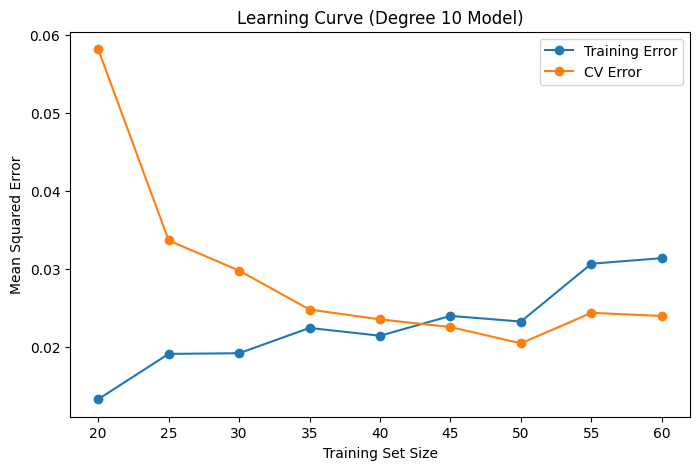

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    learning_train_errors,
    marker="o",
    label="Training Error"
)

plt.plot(
    train_sizes,
    learning_cv_errors,
    marker="o",
    label="CV Error"
)

plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curve (Degree 10 Model)")
plt.legend()

plt.show()

### Learning Curve Interpretation

The learning curve illustrates how model performance changes as additional training data becomes available.

For smaller training sets, the degree 10 polynomial model exhibits a noticeable gap between training and cross-validation error. The model achieves relatively low training error while producing higher cross-validation error, indicating variance-related behavior.

As the training set size increases, cross-validation error decreases steadily and approaches the training error. This suggests that the model becomes more stable and generalizes more effectively when provided with additional data.

The narrowing gap between training and cross-validation performance indicates that increasing the amount of training data can help mitigate variance and improve model performance on unseen examples.

## Regularization Experiment

Regularization is commonly used to reduce model complexity and improve generalization.

In this experiment, Ridge Regression is applied to a degree 10 polynomial model using different regularization strengths. Training and cross-validation errors are compared to investigate the impact of regularization on model performance.

In [15]:
from sklearn.linear_model import Ridge

alphas = [0, 0.01, 0.1, 1, 10]

ridge_train_errors = []
ridge_cv_errors = []

degree = 10

poly = PolynomialFeatures(
    degree=degree,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train)
X_cv_poly = poly.transform(X_cv)

for alpha in alphas:

    model = Ridge(alpha=alpha)

    model.fit(
        X_train_poly,
        y_train
    )

    train_pred = model.predict(X_train_poly)
    cv_pred = model.predict(X_cv_poly)

    train_mse = mean_squared_error(y_train, train_pred)
    cv_mse = mean_squared_error(y_cv, cv_pred)

    ridge_train_errors.append(train_mse)
    ridge_cv_errors.append(cv_mse)

In [16]:
ridge_results = pd.DataFrame({
    "Alpha": alphas,
    "Train MSE": ridge_train_errors,
    "CV MSE": ridge_cv_errors
})

ridge_results

,Alpha,Train MSE,CV MSE
0,0.00,0.031402,0.023992
1,0.01,0.031405,0.023756
2,0.10,0.031630,0.022167
3,1.00,0.037384,0.022512
4,10.00,0.065509,0.068321


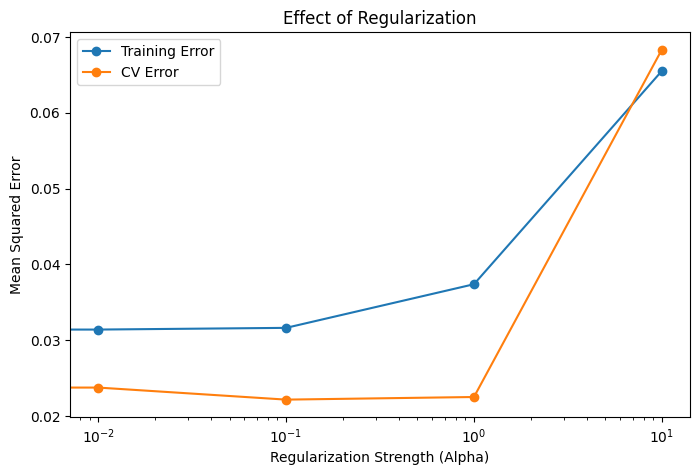

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    alphas,
    ridge_train_errors,
    marker="o",
    label="Training Error"
)

plt.plot(
    alphas,
    ridge_cv_errors,
    marker="o",
    label="CV Error"
)

plt.xscale("log")

plt.xlabel("Regularization Strength (Alpha)")
plt.ylabel("Mean Squared Error")
plt.title("Effect of Regularization")
plt.legend()

plt.show()

### Regularization Interpretation

The regularization experiment investigated whether penalizing model complexity could improve generalization performance.

For this dataset, increasing the regularization strength consistently increased both training and cross-validation error. The lowest cross-validation error was achieved when no regularization was applied.

These results suggest that the degree 10 polynomial model was not experiencing severe overfitting. As regularization increased, the model became less flexible and lost its ability to accurately capture the underlying relationship in the data.

This experiment demonstrates that regularization is not universally beneficial. While it can reduce variance in highly overfit models, excessive regularization may introduce additional bias and reduce overall performance.

## Discussion

Two complementary diagnostic techniques were explored in this notebook: learning curves and regularization.

The learning curve experiment showed that cross-validation performance improved as additional training data became available. The narrowing gap between training and cross-validation error suggested that the model became more stable and generalized better when trained on larger datasets.

The regularization experiment demonstrated that increasing regularization strength did not improve performance for this particular problem. Instead, both training and cross-validation errors increased, indicating that the original model was not severely overfitting.

Together, these experiments illustrate how bias and variance can be investigated through empirical analysis rather than intuition alone.

## Conclusion

This notebook explored the concepts of bias, variance, learning curves, and regularization using polynomial regression models.

Bias and variance were first examined through models of varying complexity. Learning curves were then used to investigate how model performance changed as additional training data became available. Finally, regularization was applied to evaluate its effect on generalization performance.

The experiments demonstrated that learning curves provide valuable insight into model behavior and can help determine whether collecting additional data is likely to improve performance. Furthermore, the results showed that regularization must be applied carefully, as excessive regularization can reduce model performance by increasing bias.

Overall, the notebook highlights practical techniques for diagnosing model performance and deciding what actions to take during machine learning development.

## Key Takeaways

- High bias is associated with underfitting and poor training performance.
- High variance is associated with overfitting and poor generalization.
- Learning curves help diagnose bias and variance.
- Additional training data can improve generalization performance.
- Regularization controls model complexity by penalizing large coefficients.
- Regularization is not always beneficial and should be validated empirically.
- Model improvement should be guided by evidence rather than assumptions.